In [40]:
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
import numpy as np
from scipy.stats import lognorm, kstest

import sys
from pathlib import Path
sys.path.append(str(Path("../src").resolve()))

warnings.simplefilter(action="ignore", category=FutureWarning)

from dataloader import load_data_csv
from preprocessor import Preprocessor
from config import Config


In [41]:
config_path = Path("../config.toml").resolve()
config = Config.load(config_path)
df = load_data_csv(config)

preprocessor = Preprocessor(config)
df = preprocessor.run()
df

2025-03-29 12:20:54.006 | INFO     | dataloader:load_data_csv:36 - Data geladen met 9899 rijen.
2025-03-29 12:20:54.065 | INFO     | dataloader:load_data_csv:36 - Data geladen met 9899 rijen.
2025-03-29 12:20:54.095 | INFO     | preprocessor:clean_authors:27 - Authors opgeschoond.
2025-03-29 12:20:54.103 | INFO     | preprocessor:anonymize_authors:46 - 13 auteurs geanonimiseerd.
2025-03-29 12:20:54.114 | INFO     | preprocessor:add_message_length:51 - Kolom 'message_length' toegevoegd met lengte van elk bericht.
2025-03-29 12:20:54.133 | INFO     | preprocessor:add_author_info:57 - Auteur-info toegevoegd voor 13 auteurs.
2025-03-29 12:20:54.209 | INFO     | preprocessor:filter_automatic_messages:68 - 1534 automatische berichten verwijderd.
2025-03-29 12:20:54.246 | INFO     | preprocessor:filter_messages_after_september_2023:79 - 154 berichten vóór 1 september 2023 verwijderd.


,timestamp,author,message,message_length,age,gender,is_inlaw
196,2023-09-01 10:53:30,sprightly-rhinoceros,Wat we triestig weer zeg man man man\n,38,33.0,m,0.0
197,2023-09-01 10:56:11,snappy-ermine,Pff echt he\n,13,30.0,m,0.0
198,2023-09-01 10:56:39,decorated-shark,Duurt nog ff....pfffff 😢\n,26,55.0,f,0.0
199,2023-09-01 10:57:03,snappy-ermine,Na vandaag wel goed weer op komst lijkt 👌🏼\n,44,30.0,m,0.0
200,2023-09-01 10:58:44,decorated-shark,"Oh, gelukkig.\n",15,55.0,f,0.0
...,...,...,...,...,...,...,...
9893,2025-03-16 16:12:35,good-natured-ermine,Als ze aan zet echt niet normaal\n,34,25.0,f,0.0
9894,2025-03-16 17:16:14,crystalline-turkey,"Thanks 😊\nFf tussenstop op Tenerife, crew wis...",62,37.0,m,0.0
9895,2025-03-16 22:33:05,crystalline-turkey,"Wij zijn weer in Nederland, net de wieltjes w...",62,37.0,m,0.0
9896,2025-03-17 07:24:32,groovy-salmon,Welcome back! 💪🏻\n,18,35.0,m,0.0


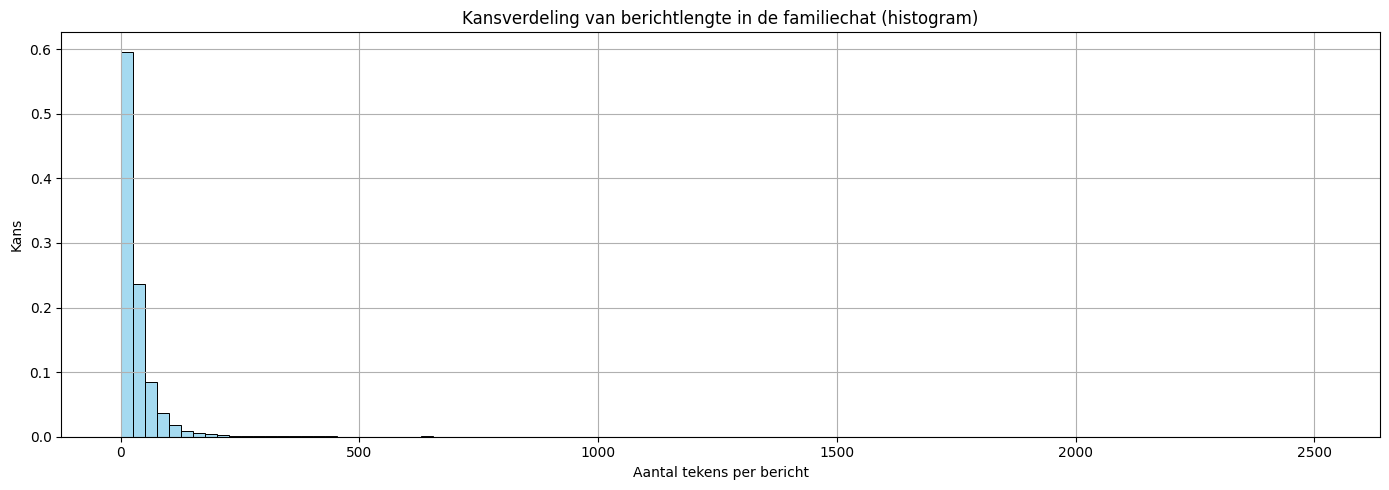

In [42]:
# Plot histogram
plt.figure(figsize=(14, 5))
sns.histplot(
    data=df,
    x="message_length",
    bins=100, 
    stat="probability",  # y-as = kans, niet frequentie
    color="skyblue",
    edgecolor="black"
)

plt.xlabel("Aantal tekens per bericht")
plt.ylabel("Kans")
plt.title("Kansverdeling van berichtlengte in de familiechat (histogram)")
plt.grid(True)
plt.tight_layout()
plt.show()

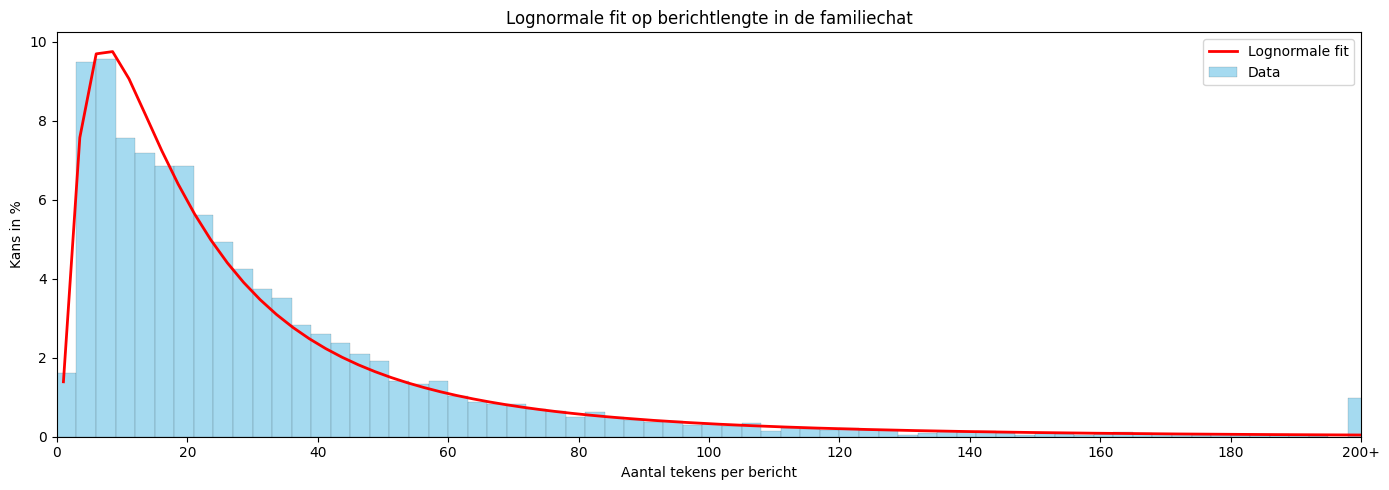

In [52]:
# Alleen positieve lengtes
message_lengths = df["message"].str.len()
positive_lengths = message_lengths[message_lengths > 0]

# Maak bins: 0–200 in stappen van 1 + alles daarboven in 1 bin
bins = list(range(0, 200, 3)) + [positive_lengths.max()]

# Lognormale fit
shape, loc, scale = lognorm.fit(positive_lengths, floc=0)
x = np.linspace(positive_lengths.min(), positive_lengths.max(), 1000)
pdf = lognorm.pdf(x, shape, loc=loc, scale=scale)

# Schaal naar percentage: pdf * 100 * binbreedte
bin_width = np.diff(bins)[0]  # bijvoorbeeld 1
pdf_scaled = pdf * 100 * bin_width

# Plot histogram met aangepaste bins
plt.figure(figsize=(14, 5))
sns.histplot(
    positive_lengths,
    bins=bins,
    stat="percent",
    color="skyblue",
    edgecolor="black",
    label="Data"
)

# Plot fit
plt.plot(x, pdf_scaled, "r", lw=2, label="Lognormale fit")
plt.xlim(0, 200)
xticks = list(range(0, 200, 20)) + [200]
xtick_labels = [str(x) for x in xticks[:-1]] + ['200+']
plt.xticks(xticks, xtick_labels)

# Extra labels
plt.xlabel("Aantal tekens per bericht")
plt.ylabel("Kans in %")
plt.title("Lognormale fit op berichtlengte in de familiechat")
plt.legend()
plt.tight_layout()
plt.show()



### 🗨️ Berichtlengte in de familiechat

De meeste berichten in de familiechat zijn kort en krachtig: zo'n **3 tot 4% van de berichten bevat maar 5 tot 10 tekens**. Dat zie je aan de piek links in de grafiek. Denk aan dingen als *“oké”*, of gewoon één emoji.

De kans op langere berichten daalt daarna gestaag, maar verdwijnt niet. Er zijn ook flink wat langere berichten, en dat past bij de familiechat waar soms een verhaal wordt getypt, een krantenartikel wordt doorgestuurd of een vakantie-update wordt gedeeld.

De rode lijn is een **lognormale verdeling**, en die past, lijkt mij, goed:

- het model voorspelt de scherpe piek bij korte berichten,  
- en laat ook zien dat langere berichten nog wel voorkomen, maar met steeds kleinere kans.

Die uitschieter aan het eind? Dat zijn berichten van **200+ tekens**, zeldzaam, maar wel degelijk aanwezig. 


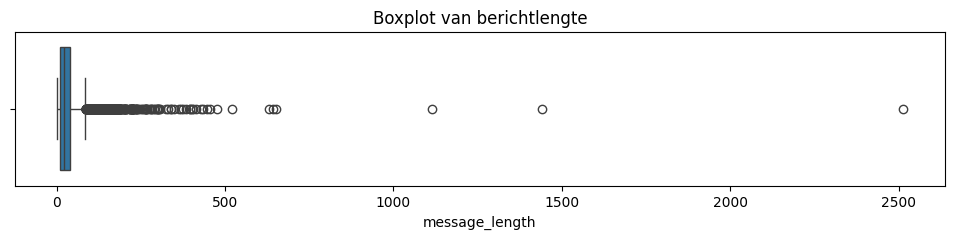

In [44]:
plt.figure(figsize=(12, 2))
sns.boxplot(x=df["message_length"])
plt.title("Boxplot van berichtlengte")
plt.show()


In [45]:
# Sorteer op lengte om de langste berichten te zien
longest_msgs = df.sort_values(by="message_length", ascending=False).head(10)
display(longest_msgs[["timestamp", "author", "message_length", "message"]])

,timestamp,author,message_length,message
9786,2025-03-06 18:30:34,pearlescent-ostrich,2512,\n\n“Dus stemden ze ervoor om een ​​muur te bo...
1800,2023-11-25 11:24:17,amusing-owl,1440,Mensen willen graag een bepaalde dag maar de ...
5196,2024-06-27 08:37:06,groovy-salmon,1113,"Best Lionel Messi,\n\nI heur you have nou bou..."
1846,2023-11-25 13:10:03,amusing-owl,650,De problemen met inloggen blijven helaas aan...
5761,2024-07-17 08:42:51,decorated-shark,643,"\nHalf 11 in t mortuarium, dan kan er nog iets..."
2836,2024-01-16 09:05:00,decorated-shark,630,"Goedemorgen samen, afgelopen maanden heb ik v..."
4757,2024-05-27 12:46:28,groovy-salmon,520,"Ja ik wil in de auto stappen, en zie ik ieman..."
1208,2023-10-26 19:08:03,crystalline-turkey,476,Gezien volgende week zat Sev z’n verjaardag i...
7100,2024-09-20 23:13:15,snappy-ermine,456,"Hoi hoi allen, volgende week zaterdag willen ..."
1363,2023-11-06 17:11:16,amusing-owl,446,Nee we hebben meer leden als we ieder 2 passe...


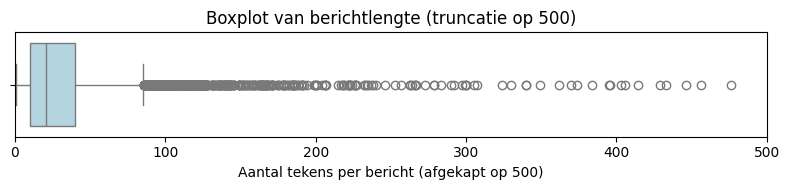

In [46]:
plt.figure(figsize=(8, 2))
sns.boxplot(x=df["message_length"], color="lightblue")
plt.xlim(0, 500)
plt.xlabel("Aantal tekens per bericht (afgekapt op 500)")
plt.title("Boxplot van berichtlengte (truncatie op 500)")
plt.tight_layout()
plt.show()


In [47]:
# Bekijk de verdeling
top_lengtes = df["message_length"].value_counts().sort_values(ascending=False)
print("Top meest voorkomende berichtlengtes:\n", top_lengtes.head())

# Filter op de uitschieter-lengte, bijvoorbeeld 25
uitschieter_waarde = top_lengtes.idxmax()  # pakt de meest voorkomende lengte automatisch
uitschieter_waarde
df[df["message_length"] == 20][["timestamp", "author", "message"]]

Top meest voorkomende berichtlengtes:
 message_length
6     341
3     316
4     270
8     247
11    225
Name: count, dtype: int64


,timestamp,author,message
269,2023-09-03 20:58:32,crystalline-turkey,Gvd lang vliegen 🫣\n
288,2023-09-05 13:51:48,merry-sparrow,Lekker genieten!😘😘\n
365,2023-09-09 09:24:44,variegated-nightingale,Gunstig voor ons 😜\n
484,2023-09-15 12:13:34,amusing-owl,Aanhanger is leeg.\n
488,2023-09-15 12:24:10,snappy-ermine,"Mooii, meevaller 😁\n"
...,...,...,...
9496,2025-02-21 19:41:13,decorated-shark,Dan zie je t niet\n
9597,2025-02-23 12:47:41,sprightly-rhinoceros,Heerlijk weertje 😊\n
9721,2025-03-02 16:05:01,good-natured-ermine,Woar stoan jullie?\n
9740,2025-03-03 18:14:30,good-natured-ermine,Volgend jaar Hahah\n


In [48]:
# Zorg dat je de message_length kolom hebt
df['message_length'] = df['message'].astype(str).str.len()
positive_lengths = df['message_length'][df['message_length'] > 0]

# Fit een lognormale verdeling op de data
shape, loc, scale = lognorm.fit(positive_lengths, floc=0)

# Voer de KS-test uit
ks_statistic, p_value = kstest(positive_lengths, 'lognorm', args=(shape, loc, scale))

# Resultaat printen
print(f"KS-statistic: {ks_statistic:.4f}")
print(f"P-waarde: {p_value:.4f}")

# Interpretatie
if p_value < 0.05:
    print("De verdeling wijkt erg af van een lognormale verdeling.")
else:
    print("De verdeling wijkt niet erg af van een lognormale verdeling.")


KS-statistic: 0.0380
P-waarde: 0.0000
De verdeling wijkt erg af van een lognormale verdeling.
